In [41]:
# Cell 0 — Setup
import sys, os
sys.path.insert(0, '..')
from scripts.plotting_util import aggregate_stats_by_policy
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

STATS = '../out/rdr_micro2026/simulation_results'
PLOTS = 'plots/rdr'
os.makedirs(PLOTS, exist_ok=True)

C1='#1f4529'; C2='#f5f4b3'; C3='#abba7c'; C4='#898121'

BENCHMARKS = ['BQ_bose_hubbard_q', 'BQ_chromium_q', 'BQ_manganese_nitride_q', 'BQ_hc3h2cn_q',
              'BQ_bose_hubbard_t', 'BQ_chromium_t', 'BQ_manganese_nitride_t', 'BQ_hc3h2cn_t',
              'BQ_grover_3sat_schoning_1710', 'BQ_qaoa_random', 'BQ_qaoa_3regular', 'BQ_qaoa_powerlaw']
TICKS = ['bose_hubbard_Q','chromium_Q','manganese_Q','hc3h2cn_Q',
         'bose_hubbard_T','chromium_T','manganese_T','hc3h2cn_T',
         'grover_3sat','qaoa_random','qaoa_3regular','qaoa_powerlaw']
BASE_FACTORY = 33540

# Code distance used for the RLTP workspace footprint formula.
D_CODE = 23

def rltp_workspace_qubits(n):
    # Physical qubits for the RLTP-n workspace:  (11/2) * n * 2 * (d+1)^2.
    # (RLTP overhead does not affect timing stats, so this can be computed analytically
    #  rather than read from the simulation output.)
    return (11/2) * n * 2 * (D_CODE + 1)**2

def rltp_n_for(folder_prefix):
    # Map a results-folder prefix to its RLTP order n (folder index), or None for
    # policies with no RLTP workspace (e.g. plain RDR, baseline).
    #   rltp_4 -> 4, rltp_6 -> 6, rltp_8 -> 8;  rdr_with_rltp -> 4 (uses RLTP-5)
    if folder_prefix == 'rdr_with_rltp':
        return 4
    if folder_prefix.startswith('rltp_'):
        return int(folder_prefix.split('_')[1])
    return None

def kips(stats, b):
    return stats[b]['CLIENT 0']['KIPS']

def rel_footprint(stats, b, rltp_n=None):
    # The RLTP workspace is the minimum of the value recorded in the simulation
    # output and the analytic formula (rltp_workspace_qubits) when rltp_n is given.
    s = stats[b]
    rltp_ws = s['COMPUTE_FOOTPRINT'].get('RLTP_WORKSPACE', 0)
    if rltp_n is not None:
        rltp_ws = rltp_workspace_qubits(rltp_n)
    return (s['FACTORY_FOOTPRINT']['TOTAL']
            + rltp_ws
            + s['COMPUTE_FOOTPRINT'].get('RDR_WORKSPACE', 0)) / BASE_FACTORY

def speedup_pct(policy_stats, base_stats, benchmarks):
    return [(kips(policy_stats, b) / kips(base_stats, b) - 1)*100 for b in benchmarks]

def gmean_speedup_pct(policy_stats, base_stats, benchmarks):
    ratios = [kips(policy_stats, b) / kips(base_stats, b) for b in benchmarks]
    return (sp.stats.gmean(ratios) - 1) * 100

FACTORY_CONFIGS = ['f35k', 'f40k', 'f50k', 'f55k', 'f60k', 'f70k', 'f75k']

# Shared baseline — all speedups are relative to this
base_f35k = aggregate_stats_by_policy(f'{STATS}/baseline_f35k')

RLTP-5 (1.8×) 13.76218136633398
RDPC (1.8×) 50.1809341173139
RLTP-5 (2.2×) 29.036392772662587
RDPC (2.2×) 58.786749294744034


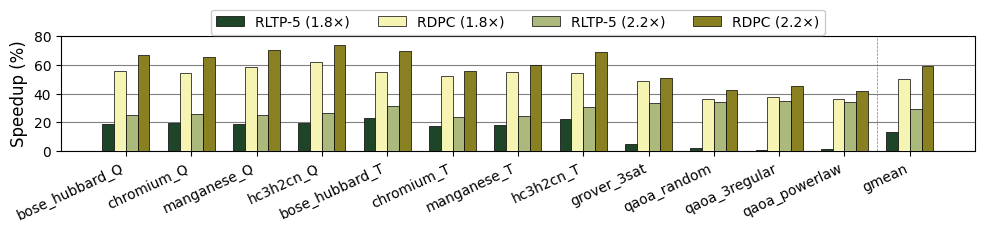

Saved fig11_iso_footprint_speedup.pdf


In [48]:
# Cell 2 — Figure 11: Iso-footprint speedup (double col, 10.0x2.4)

base_f35k  = aggregate_stats_by_policy(f'{STATS}/baseline_f35k')
rdr_f50k   = aggregate_stats_by_policy(f'{STATS}/rdr_f55k')
rltp4_f35k = aggregate_stats_by_policy(f'{STATS}/rltp_4_f35k')
rdr_f70k   = aggregate_stats_by_policy(f'{STATS}/rdr_f70k')
rltp4_f50k = aggregate_stats_by_policy(f'{STATS}/rltp_4_f50k')

rep_b = BENCHMARKS[0]
# RLTP footprints use min(reported workspace, analytic formula) with RLTP-5 -> n=4.
fp_rdr_f50k   = rel_footprint(rdr_f50k,   rep_b)
fp_rltp4_f35k = rel_footprint(rltp4_f35k, rep_b, rltp_n=4)
fp_rdr_f70k   = rel_footprint(rdr_f70k,   rep_b)
fp_rltp4_f50k = rel_footprint(rltp4_f50k, rep_b, rltp_n=4)

configs = [
    (rltp4_f35k, C1, f'RLTP-5 ({fp_rltp4_f35k:.1f}×)'),
    (rdr_f50k,   C2, f'RDPC ({fp_rdr_f50k:.1f}×)'),
    (rltp4_f50k, C3, f'RLTP-5 ({fp_rltp4_f50k:.1f}×)'),
    (rdr_f70k,   C4, f'RDPC ({fp_rdr_f70k:.1f}×)'),
]

fig, ax = plt.subplots(figsize=(10.0, 2.4))

n_benchmarks_plus_gmean = len(BENCHMARKS) + 1
n_configs = len(configs)
width = 0.18
x = np.arange(n_benchmarks_plus_gmean)

for i, (policy_stats, color, label) in enumerate(configs):
    speedups = speedup_pct(policy_stats, base_f35k, BENCHMARKS)
    gm = gmean_speedup_pct(policy_stats, base_f35k, BENCHMARKS)
    print(label, gm)
    values = speedups + [gm]
    offset = (i - n_configs / 2 + 0.5) * width
    ax.bar(x + offset, values, width, label=label, color=color,
           edgecolor='black', linewidth=0.5, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(TICKS + ['gmean'], fontsize=10, rotation=25, ha='right')
ax.set_ylabel('Speedup (%)', fontsize=12)
ax.legend(fontsize=10, ncol=4, loc='lower center', bbox_to_anchor=(0.5, 0.95), framealpha=1.0)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(len(BENCHMARKS) - 0.5, color='gray', linewidth=0.5, linestyle='--')
ax.tick_params(axis='y', labelsize=10)
ax.grid(axis='y', linestyle='-', color='gray', zorder=0)
ax.set_ylim(0,80.0)

plt.tight_layout()
plt.savefig(f'{PLOTS}/v2_fig11_iso_footprint_speedup.pdf', bbox_inches='tight')
plt.show()
print('Saved fig11_iso_footprint_speedup.pdf')

RDPC 1.2082289803220037 10.673333934204997
RDPC 1.396541443053071 30.10329648445427
RDPC 1.6082289803220036 41.52605170212114
RDPC 1.8082289803220035 50.1809341173139
RDPC 1.996541443053071 56.4938830068739
RDPC 2.2082289803220037 58.786749294744034
RDPC 2.4082289803220034 59.03414305063557
RLTP-5 1.755635062611807 13.76218136633398
RLTP-5 1.9439475253428742 23.961113014085655
RLTP-5 2.1556350626118066 29.036392772662587
RLTP-5 2.3556350626118068 32.12700110359541
RLTP-5 2.5439475253428743 32.948948518287956
RLTP-5 2.7556350626118067 33.10235650140392
RLTP-5 2.955635062611807 33.12499352108696
RLTP-7 2.1334525939177102 15.315914047927937
RLTP-7 2.3217650566487777 32.57351655025074
RLTP-7 2.53345259391771 42.46088732925748
RLTP-7 2.7334525939177103 47.51316206976237
RLTP-7 2.9217650566487774 51.422347615919016
RLTP-7 3.1334525939177102 53.96854788380572
RLTP-7 3.33345259391771 55.490094865794305


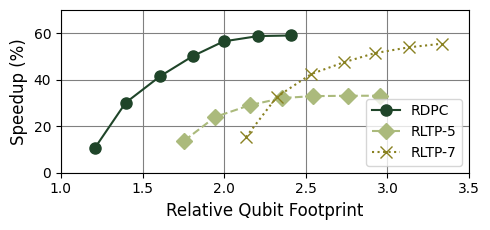

Saved fig12_footprint_vs_speedup.pdf


In [50]:
# Cell 3 — Figure 12: Footprint vs speedup (single col, 5.0x2.4)

lines = [
    ('rdr',    C1, 'o-', 'RDPC'),
    ('rltp_4', C3, 'D--', 'RLTP-5'),
    ('rltp_6', C4, 'x:', 'RLTP-7'),
]

fig, ax = plt.subplots(figsize=(5.0, 2.4))

for (folder_prefix, color, marker, label) in lines:
    xs, ys = [], []
    for fc in FACTORY_CONFIGS:
        policy_folder = f'{STATS}/{folder_prefix}_{fc}'
        if not os.path.isdir(policy_folder):
            continue
        policy_stats = aggregate_stats_by_policy(policy_folder)
        valid_bs = [b for b in BENCHMARKS
                    if b in policy_stats and b in base_f35k]
        if not valid_bs:
            continue
        fp = rel_footprint(policy_stats, valid_bs[0], rltp_n=rltp_n_for(folder_prefix))
        gm = gmean_speedup_pct(policy_stats, base_f35k, valid_bs)
        xs.append(fp)
        ys.append(gm)
        print(label, fp, gm)
    ax.plot(xs, ys, marker, color=color, label=label,
            linewidth=1.5, markersize=8, zorder=3)

ax.set_xlabel('Relative Qubit Footprint', fontsize=12)
ax.set_ylabel('Speedup (%)', fontsize=12)
ax.legend(fontsize=10)
ax.tick_params(axis='both', labelsize=10)
ax.grid(axis='both', linestyle='-', color='gray', zorder=0)
ax.set_xlim(1.0, 3.5)
ax.set_ylim(0.0, 70.0)

plt.tight_layout()
plt.savefig(f'{PLOTS}/v2_fig12_footprint_vs_speedup.pdf', bbox_inches='tight')
plt.show()
print('Saved fig12_footprint_vs_speedup.pdf')

coverage = 80.69882890233703, timeliness = 84.009188307597


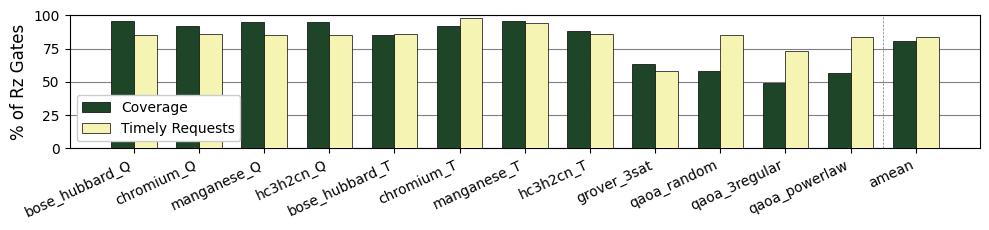

Saved fig13_coverage_timeliness.pdf


In [51]:
# Cell 4 — Figure 13: Coverage and timeliness (double col, 10.0x2.4)

rdr_stats = aggregate_stats_by_policy(f'{STATS}/rdr_f70k')

coverages    = []
timelinesses = []
for b in BENCHMARKS:
    s = rdr_stats[b]
    total       = s['TOTAL_ROTATION_INSTRUCTIONS']
    submitted   = s['RDR_REQUESTS_SUBMITTED']
    started     = s['RDR_REQUESTS_STARTED']
    completed   = s['RDR_REQUESTS_COMPLETED']
    interrupted = s['RDR_REQUESTS_INTERRUPTED']
    cov = started / total * 100
    tim = (completed - interrupted) / started * 100
    coverages.append(cov)
    timelinesses.append(tim)

amean_cov = np.mean(coverages)
amean_tim = np.mean(timelinesses)

print(f'coverage = {amean_cov}, timeliness = {amean_tim}')

fig, ax = plt.subplots(figsize=(10.0, 2.4))

n = len(BENCHMARKS) + 1
x = np.arange(n)
width = 0.35

all_cov = coverages + [amean_cov]
all_tim = timelinesses + [amean_tim]

ax.bar(x - width/2, all_cov, width, label='Coverage',        color=C1, edgecolor='black', linewidth=0.5, zorder=3)
ax.bar(x + width/2, all_tim, width, label='Timely Requests', color=C2, edgecolor='black', linewidth=0.5, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(TICKS + ['amean'], fontsize=10, rotation=25, ha='right')
ax.set_ylabel('% of Rz Gates', fontsize=12)
ax.set_ylim(0, 100)
ax.legend(fontsize=10, loc='lower left', framealpha=1.0)
ax.axvline(len(BENCHMARKS) - 0.5, color='gray', linewidth=0.5, linestyle='--')
ax.tick_params(axis='y', labelsize=10)
ax.grid(axis='y', linestyle='-', color='gray', zorder=0)

plt.tight_layout()
plt.savefig(f'{PLOTS}/v2_fig13_coverage_timeliness.pdf', bbox_inches='tight')
plt.show()
print('Saved fig13_coverage_timeliness.pdf')

tr1 --------
RDR 1.2082289803220037 0.7628766921482288
RDR 1.396541443053071 16.756819161199953
RDR 1.6082289803220036 28.974849447726836
RDR 1.8082289803220035 34.58978248727165
RDR 1.996541443053071 49.33649049366971
RDR 2.2082289803220037 53.14119487253996
RDR 2.4082289803220034 56.69394363110531
RLTP-5 1.755635062611807 0.4958347976231847
RLTP-5 1.9439475253428742 16.947532820609034
RLTP-5 2.1556350626118066 30.388593148186093
RLTP-5 2.3556350626118068 39.61211649888921
RLTP-5 2.5439475253428743 44.909197915848175
RLTP-5 2.7556350626118067 47.39871982706263
RLTP-5 2.955635062611807 49.341413498163966
RLTP-7 2.1334525939177102 0.9826558999164847
RLTP-7 2.3217650566487777 17.746054168099402
RLTP-7 2.53345259391771 33.657853010422365
RLTP-7 2.7334525939177103 48.204400605700656
RLTP-7 2.9217650566487774 59.173222959917204
RLTP-7 3.1334525939177102 67.7576471763371
RLTP-7 3.33345259391771 73.24150368224676
tr23 --------
RDR 1.2082289803220037 33.0184146842454
RDR 1.396541443053071 44.7

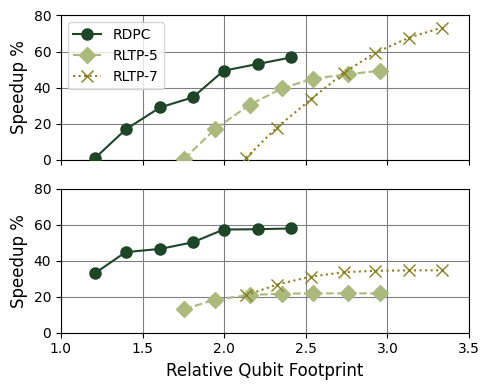

Saved fig15_reaction_time_sensitivity.pdf


In [56]:
# Cell 6 — Figure 15: Reaction time sensitivity (single col, 5.0x4.8 with 2 subplots)

TR_FACTORY_CONFIGS = FACTORY_CONFIGS

base_tr1  = aggregate_stats_by_policy(f'{STATS}/baseline_f35k_tr1')
base_tr23 = aggregate_stats_by_policy(f'{STATS}/baseline_f35k_tr23')

def collect_tr_line(folder_prefix, suffix, base_stats, factory_configs):
    xs, ys = [], []
    rltp_n = rltp_n_for(folder_prefix)
    for fc in factory_configs:
        policy_folder = f'{STATS}/{folder_prefix}_{fc}_{suffix}'
        if not os.path.isdir(policy_folder):
            continue
        policy_stats = aggregate_stats_by_policy(policy_folder)
        valid_bs = [b for b in BENCHMARKS
                    if b in policy_stats and b in base_stats]
        if not valid_bs:
            continue
        fp = rel_footprint(policy_stats, valid_bs[0], rltp_n=rltp_n)
        gm = gmean_speedup_pct(policy_stats, base_stats, valid_bs)
        xs.append(fp)
        ys.append(gm)
    return xs, ys

fig, axes = plt.subplots(2, 1, figsize=(5.0, 4.0), sharex=True)

for ax, suffix, base_stats, ylabel_suffix in zip(
        axes,
        ['tr1',    'tr23'],
        [base_tr1, base_tr23],
        ['(tr=1)', '(tr=d)']):
    xs_rdr,   ys_rdr   = collect_tr_line('rdr',    suffix, base_stats, TR_FACTORY_CONFIGS)
    xs_rltp4, ys_rltp4 = collect_tr_line('rltp_4', suffix, base_stats, TR_FACTORY_CONFIGS)
    xs_rltp6, ys_rltp6 = collect_tr_line('rltp_6', suffix, base_stats, TR_FACTORY_CONFIGS)

    print(suffix, '--------')
    for i in range(len(xs_rdr)):
        print('RDR', xs_rdr[i], ys_rdr[i])
        
    for i in range(len(xs_rltp4)):
        print('RLTP-5', xs_rltp4[i], ys_rltp4[i])
        
    for i in range(len(xs_rltp6)):
        print('RLTP-7', xs_rltp6[i], ys_rltp6[i])
    
    ax.plot(xs_rdr,   ys_rdr,   'o-', color=C1, label='RDPC',    linewidth=1.5, markersize=8, zorder=3)
    ax.plot(xs_rltp4, ys_rltp4, 'D--', color=C3, label='RLTP-5', linewidth=1.5, markersize=8, zorder=3)
    ax.plot(xs_rltp6, ys_rltp6, 'x:', color=C4, label='RLTP-7', linewidth=1.5, markersize=8, zorder=3)

    ax.set_ylabel(f'Speedup %', fontsize=12)
    if suffix == 'tr1':
        ax.legend(fontsize=10)
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(axis='both', linestyle='-', color='gray', zorder=0)
    ax.set_xlim([1.0,3.5])
    ax.set_ylim([0.0,80.0])

axes[-1].set_xlabel('Relative Qubit Footprint', fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOTS}/v2_fig15_reaction_time_sensitivity.pdf', bbox_inches='tight')
plt.show()
print('Saved fig15_reaction_time_sensitivity.pdf')

In [21]:
# Cell 7 — RDR Rz magic-state timing: prep time + completion-buffer dwell time (cycles)
#
# Both are per-request latencies (arithmetic mean across benchmarks is appropriate):
#   prep_time = RDR_REQUEST_COMPLETION_MEAN_LATENCY      (rdr_end - rdr_start)
#   buf_time  = RDR_REQUEST_POST_COMPLETION_MEAN_IDLE_TIME (current - rdr_end)
# These are RDR-only stats (RLTP / baseline runs do not emit them).

TMAP = dict(zip(BENCHMARKS, TICKS))

# --- aggregate (mean across benchmarks) per factory config ---
print(f'{"config":<6} {"footprint":>10} {"prep_cycles":>12} {"buf_cycles":>12}')
print('-' * 44)
for fc in FACTORY_CONFIGS:
    policy_folder = f'{STATS}/rdr_{fc}'
    if not os.path.isdir(policy_folder):
        continue
    stats = aggregate_stats_by_policy(policy_folder)
    valid_bs = [b for b in BENCHMARKS if b in stats]
    if not valid_bs:
        continue
    fp   = rel_footprint(stats, valid_bs[0])
    prep = np.mean([stats[b]['RDR_REQUEST_COMPLETION_MEAN_LATENCY']        for b in valid_bs])
    buf  = np.mean([stats[b]['RDR_REQUEST_POST_COMPLETION_MEAN_IDLE_TIME'] for b in valid_bs])
    print(f'{fc:<6} {fp:>10.3f} {prep:>12.2f} {buf:>12.2f}')
print()

# --- per-workload breakdown at f70k ---
fc = 'f70k'
stats = aggregate_stats_by_policy(f'{STATS}/rdr_{fc}')
print(f'Per-workload RDR timing @ {fc}:')
print(f'{"workload":<14} {"prep_cycles":>12} {"buf_cycles":>12}')
print('-' * 40)
preps, bufs = [], []
for b in BENCHMARKS:
    if b not in stats:
        continue
    prep = stats[b]['RDR_REQUEST_COMPLETION_MEAN_LATENCY']
    buf  = stats[b]['RDR_REQUEST_POST_COMPLETION_MEAN_IDLE_TIME']
    preps.append(prep)
    bufs.append(buf)
    print(f'{TMAP[b]:<14} {prep:>12.2f} {buf:>12.2f}')
print('-' * 40)
print(f'{"mean":<14} {np.mean(preps):>12.2f} {np.mean(bufs):>12.2f}')

config  footprint  prep_cycles   buf_cycles
--------------------------------------------
f35k        1.208     14964.81      6090.09
f40k        1.397     10747.55      6858.63
f50k        1.608      7766.77      4231.56
f55k        1.808      5812.97      4695.28
f60k        1.997      4651.12      5140.82
f70k        2.208      4184.09      5493.84
f75k        2.408      4017.37      5813.02

Per-workload RDR timing @ f70k:
workload        prep_cycles   buf_cycles
----------------------------------------
bose_hubbard_Q      2630.41      3116.62
chromium_Q          2647.52      3236.26
manganese_Q         2640.80      3117.34
hc3h2cn_Q           2675.30      3098.02
bose_hubbard_T      5690.33      8278.34
chromium_T          5956.43     12891.12
manganese_T         5941.35     11462.67
hc3h2cn_T           6637.04      9222.04
grover_3sat         3667.42      2455.48
qaoa_random         3722.13      3132.26
qaoa_3regular       4209.90      2820.54
qaoa_powerlaw       3790.46      3095

In [54]:
# Cell 7b — LaTeX table: per-benchmark application fidelity (%) at iso footprint (~2.1x)
# Columns: Baseline (f35k, 1.0x), RLTP-5 (rltp_4_f50k, 2.09x), RDR (rdr_f65k, 2.14x)
# (RLTP footprint = min(reported workspace, analytic formula), n=4.)

tab_cols = [
    ('Baseline', 'baseline_f35k'),
    ('RLTP-5',   'rltp_4_f55k'),
    ('RDPC',      'rdr_f70k'),
]
tab_data = {lab: aggregate_stats_by_policy(f'{STATS}/{d}') for lab, d in tab_cols}

def _fid_pct(lab, b):
    s = tab_data[lab]
    return s[b]['FIDELITY']['OVERALL'] * 100 if b in s else None

def _tex_esc(s):
    return s.replace('_', r'\_')

lines = []
lines.append(r'\begin{tabular}{|c||c|c|c|}')
lines.append(r'\hline')
lines.append('Benchmark & ' + ' & '.join(lab for lab, _ in tab_cols) + r' \\')
lines.append(r'\hline\hline')

col_vals = {lab: [] for lab, _ in tab_cols}
for b, t in zip(BENCHMARKS, TICKS):
    cells = []
    for lab, _ in tab_cols:
        v = _fid_pct(lab, b)
        cells.append(f'{v:.1f}' if v is not None else '--')
        if v is not None:
            col_vals[lab].append(v)
    lines.append(f'{_tex_esc(t)} & ' + ' & '.join(cells) + r' \\')

lines.append(r'\hline\hline')
means = [f'{np.mean(col_vals[lab]):.1f}' for lab, _ in tab_cols]
lines.append('mean & ' + ' & '.join(means) + r' \\')
lines.append(r'\hline')
lines.append(r'\end{tabular}')

print('\n'.join(lines))

\begin{tabular}{|c||c|c|c|}
\hline
Benchmark & Baseline & RLTP-5 & RDPC \\
\hline\hline
bose\_hubbard\_Q & 99.3 & 99.4 & 99.2 \\
chromium\_Q & 98.7 & 98.9 & 98.4 \\
manganese\_Q & 98.8 & 98.9 & 98.5 \\
hc3h2cn\_Q & 98.6 & 98.7 & 98.2 \\
bose\_hubbard\_T & 99.4 & 99.4 & 99.2 \\
chromium\_T & 99.6 & 99.7 & 99.5 \\
manganese\_T & 99.6 & 99.6 & 99.5 \\
hc3h2cn\_T & 99.1 & 99.2 & 98.8 \\
grover\_3sat & 98.9 & 99.0 & 98.7 \\
qaoa\_random & 98.3 & 98.5 & 97.8 \\
qaoa\_3regular & 97.7 & 97.9 & 97.2 \\
qaoa\_powerlaw & 98.5 & 98.6 & 98.1 \\
\hline\hline
mean & 98.9 & 99.0 & 98.6 \\
\hline
\end{tabular}


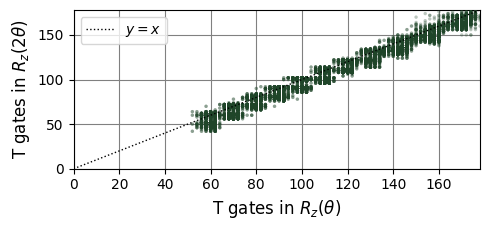

86.8% of points lie on or below y = x
Saved fig17_rz_theta_vs_2theta_tcount.pdf


In [55]:
# Cell 8 — Figure 17: Rz(theta) vs Rz(2*theta) T-gate count (single col, 5.0x2.4)

syn = np.genfromtxt('syntheses_comparison.csv', delimiter=',', names=True)
syn = syn[np.abs(syn['angle']) < 1.0]   # drop angles with |theta| >= 1
tx  = syn['t_count_x']
t2x = syn['t_count_2x']

fig, ax = plt.subplots(figsize=(5.0, 2.4))

lim = max(tx.max(), t2x.max())
ax.plot([0, lim], [0, lim], linestyle=':', color='black', linewidth=1.0,
        label='$y = x$', zorder=4)
ax.scatter(tx, t2x, s=6, color=C1, edgecolor='none', alpha=0.3, zorder=3)

ax.set_xlabel(r'T gates in $R_z(\theta)$', fontsize=12)
ax.set_ylabel(r'T gates in $R_z(2\theta)$', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.tick_params(axis='both', labelsize=10)
ax.grid(axis='both', linestyle='-', color='gray', zorder=0)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)

plt.tight_layout()
plt.savefig(f'{PLOTS}/v2_fig17_rz_theta_vs_2theta_tcount.pdf', bbox_inches='tight')
plt.show()

frac_on_or_below = np.mean(t2x <= tx) * 100
print(f'{frac_on_or_below:.1f}% of points lie on or below y = x')
print('Saved fig17_rz_theta_vs_2theta_tcount.pdf')

In [10]:
# Cell 9 — Figure 18: T-gate ratio Rz(2*theta)/Rz(theta) vs angle (single col, 5.0x2.4)

SHOW_INSET = False   # toggle the top-left zoom-in subplot (|theta| >= 1e-1)

syn = np.genfromtxt('syntheses_comparison.csv', delimiter=',', names=True)
syn = syn[np.abs(syn['angle']) < pi/8]   # drop angles with |theta| >= 1
tx  = syn['t_count_x']
t2x = syn['t_count_2x']

ang   = np.abs(syn['angle'])
ratio = t2x / tx

fig, ax = plt.subplots(figsize=(5.0, 2.4))

ax.axhline(1.0, linestyle=':', color='black', linewidth=1.0, zorder=4)
ax.scatter(ang, ratio, s=6, color=C1, edgecolor='none', alpha=0.3, zorder=3)

ax.set_xscale('log')
ax.set_xlabel(r'Rotation Angle ($\theta$)', fontsize=12)
ax.set_ylabel(r'$\rho(\theta)$', fontsize=12)
#ax.legend(fontsize=10, loc='upper right')
ax.tick_params(axis='both', labelsize=10)
ax.grid(axis='both', linestyle='-', color='gray', zorder=0)

# Zoom-in inset (top-left): angles from 1e-1 and beyond
zoom_lo = 1e-1
mask    = ang >= zoom_lo

if SHOW_INSET:
    axins = ax.inset_axes([0.10, 0.56, 0.42, 0.40])
    axins.axhline(1.0, linestyle=':', color='black', linewidth=1.0, zorder=4)
    axins.scatter(ang[mask], ratio[mask], s=6, color=C1, edgecolor='none', alpha=0.3, zorder=3)
    axins.set_xscale('log')
    axins.set_xlim(zoom_lo, ang.max() * 1.1)
    axins.set_ylim(ratio[mask].min() - 0.02, ratio[mask].max() + 0.02)
    axins.tick_params(axis='both', labelsize=7)
    axins.grid(axis='both', linestyle='-', color='gray', zorder=0)
    ax.indicate_inset_zoom(axins, edgecolor='gray')

plt.tight_layout()
plt.savefig(f'{PLOTS}/v2_fig18_tcount_ratio_vs_angle.pdf', bbox_inches='tight')

# compute statistics over ONLY the points visible within the axes limits
fig.canvas.draw()
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
vis = (ang >= x0) & (ang <= x1) & (ratio >= y0) & (ratio <= y1)
rv  = ratio[vis]
plt.show()

print(f'[{vis.sum()} of {len(ratio)} points in view] '
      f'median ratio = {np.median(rv):.3f}, mean ratio = {np.mean(rv):.3f}')
print(f'{np.mean(rv <= 1)*100:.1f}% of in-view points have ratio <= 1')
print(f'[zoom |theta|>={zoom_lo}] median ratio = {np.median(ratio[mask]):.3f}, '
      f'{np.mean(ratio[mask] <= 1)*100:.1f}% <= 1')
print('Saved fig18_tcount_ratio_vs_angle.pdf')

NameError: name 'pi' is not defined

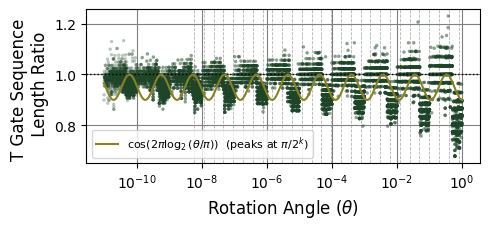

Saved fig18b_tcount_ratio_with_sinusoid.pdf


In [11]:
# Cell 10 — Figure 18 (variant): ratio vs angle with a sinusoid peaking at pi/2^k
import math
pi = math.pi

syn = np.genfromtxt('syntheses_comparison.csv', delimiter=',', names=True)
syn = syn[np.abs(syn['angle']) < 1.0]   # drop angles with |theta| >= 1
tx  = syn['t_count_x']
t2x = syn['t_count_2x']

ang   = np.abs(syn['angle'])
ratio = t2x / tx

GOLDEN_RATIO = 1.61803398875

# Sinusoid whose PEAKS land exactly on theta = pi/2^k.
# cos(2*pi*log2(theta/pi)) == 1 whenever log2(theta/pi) is an integer, i.e. theta = pi/2^k.
SIN_AMP    = 0.05                 # amplitude of the overlaid sinusoid
SIN_CENTER = np.median(ratio)     # vertical center of the sinusoid
xx  = np.logspace(np.log10(ang.min()), np.log10(ang.max()), 2000)
yy  = SIN_CENTER + SIN_AMP * np.cos(1.0/GOLDEN_RATIO * pi * np.log2(xx / pi))

fig, ax = plt.subplots(figsize=(5.0, 2.4))

ax.axhline(1.0, linestyle=':', color='black', linewidth=1.0, zorder=4)
ax.scatter(ang, ratio, s=6, color=C1, edgecolor='none', alpha=0.3, zorder=3)
ax.plot(xx, yy, color=C4, linewidth=1.5, zorder=5,
        label=r'$\cos(2\pi\log_2(\theta/\pi))$  (peaks at $\pi/2^k$)')

# mark the pi/2^k peak locations
ks = np.arange(0, 30)
peaks = pi / (2.0 ** ks)
peaks = peaks[(peaks >= ang.min()) & (peaks <= ang.max())]
for x0 in peaks:
    ax.axvline(x0, linestyle='--', color='gray', linewidth=0.6, alpha=0.6, zorder=1)

ax.set_xscale('log')
ax.set_xlabel(r'Rotation Angle ($\theta$)', fontsize=12)
ax.set_ylabel('T Gate Sequence \n Length Ratio', fontsize=12)
ax.legend(fontsize=8, loc='lower left')
ax.tick_params(axis='both', labelsize=10)
ax.grid(axis='both', linestyle='-', color='gray', zorder=0)

plt.tight_layout()
plt.savefig(f'{PLOTS}/v2_fig18b_tcount_ratio_with_sinusoid.pdf', bbox_inches='tight')
plt.show()
print('Saved fig18b_tcount_ratio_with_sinusoid.pdf')
